# Notebook 04: Regression Modelling — BMI Prediction

## Objective

This notebook develops and compares regression models for predicting Body Mass Index (BMI) among adult NHANES participants.

The target variable is BMXBMI (Body Mass Index, kg/m²). 

Predictors include selected demographic, socioeconomic, lifestyle and clinical characteristics retained from the cleaned analytical dataset.

Eight regression algorithms are evaluated using the same training and test datasets. Model performance is assessed using:

- R² (coefficient of determination)
- RMSE (root mean squared error)
- MAE (mean absolute error)

The analysis also examines the influence of waist circumference on predictive performance because exploratory analysis showed a very strong relationship between waist circumference and BMI.

### Step 1. Import Libraries and Download Dataset

In [1]:
# Import Libraries and Load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

# Download Dataset
df = pd.read_csv("../outputs/NHANES_Cleaned_Adults.csv")

# Verify download was effective
print("Dataset shape:", df.shape)
print("Participants:", len(df))

Dataset shape: (16943, 48)
Participants: 16943


### Step 2. Define Target and Predictors

Body Mass Index (BMI; `BMXBMI`) was selected as the continuous target variable.

Predictors included selected demographic, socioeconomic, anthropometric, clinical, laboratory, lifestyle and health-related variables retained from the cleaned analytical dataset.

The predictors were separated into continuous and categorical variables to
allow appropriate preprocessing before model training.

In [2]:
# Define target
target = "BMXBMI"

# Continuous predictors
continuous_features = [
    "RIDAGEYR", 
    "INDFMPIR",
    "BMXWAIST",
    "BPXSY1",
    "BPXDI1",
    "LBDHDD",
    "LBXTC",
    "LBXGH",
    "PAD680"
]

# Categorical predictors
categorical_features = [
    "RIAGENDR",
    "RIDRETH3",
    "DMDEDUC2",
    "DMDMARTL",
    "SMQ020",
    "PAQ605",
    "PAQ620",
    "PAQ650",
    "DUQ200",
    "DIQ010",
    "DIQ160",
    "MCQ160A",
    "MCQ160B",
    "MCQ160C",
    "MCQ160E",
    "MCQ160F",
    "DPQ020",
    "WHQ030"
]

# Combine predictors
predictor_vars = continuous_features + categorical_features

X = df[predictor_vars].copy()
y = df[target].copy()

print("Target:", target)
print("Continuous predictors:", len(continuous_features))
print("Categorical predictors:", len(categorical_features))
print("Total predictors:", len(predictor_vars))
print("X shape:", X.shape)
print("y shape:", y.shape)

Target: BMXBMI
Continuous predictors: 9
Categorical predictors: 18
Total predictors: 27
X shape: (16943, 27)
y shape: (16943,)


### Step 3. Train/Test Split and Data Preprocessing

The data were divided into training (80%) and testing (20%) sets using a fixed
random seed (`random_state=42`) for reproducibility.

Continuous predictors were imputed using the median and standardised using
`StandardScaler`. Categorical predictors were imputed using the most frequent
category and transformed using one-hot encoding.

All preprocessing steps were defined within a scikit-learn preprocessing pipeline and subsequently incorporated into each modelling pipeline. This ensures that imputation, scaling and one-hot encoding are learned from the training data and then applied to the test data, reducing the risk of data leakage.

In [3]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

# Continuous-variable preprocessing
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical-variable preprocessing
categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
preprocessor = ColumnTransformer([
    ("num", numeric_transformer, continuous_features),
    ("cat", categorical_transformer, categorical_features)
])

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Training set: (13554, 27)
Test set: (3389, 27)


### Step 4. Regression Model Comparison

Eight regression algorithms were evaluated using identical preprocessing and
training/test partitions:

- Linear Regression
- Ridge Regression
- Lasso Regression
- Decision Tree
- Random Forest
- Gradient Boosting
- Support Vector Regression
- K-Nearest Neighbours

Models were compared using R², RMSE and MAE.

In [4]:
# 4.1. Model Performance Metrics

models = {
    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(alpha=1.0),

    "Lasso Regression": Lasso(alpha=0.01),

    "Decision Tree": DecisionTreeRegressor(random_state=42),

    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1),

    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200,
        learning_rate=0.05, max_depth=3, random_state=42),

    "SVR": SVR(),

    "KNN Regressor": KNeighborsRegressor(n_neighbors=5)
}

regression_results = []
fitted_models = {}

for name, regressor in models.items():
    model = Pipeline([("preprocessor", preprocessor),("regressor", regressor)])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    regression_results.append({
        "Model": name,
        "R2": r2_score(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAE": mean_absolute_error(y_test, y_pred)})

    fitted_models[name] = model

regression_results = pd.DataFrame(
    regression_results).sort_values("R2",ascending=False).reset_index(drop=True)

pd.set_option('display.precision', 4)

regression_results

,Model,R2,RMSE,MAE
0,Random Forest,0.8576,2.7918,1.9518
1,Gradient Boosting,0.8500,2.8649,1.9535
2,Lasso Regression,0.8286,3.0630,2.0550
3,Linear Regression,0.8283,3.0656,2.0654
4,Ridge Regression,0.8283,3.0657,2.0653
5,SVR,0.8237,3.1067,2.0093
6,KNN Regressor,0.7022,4.0370,2.9149
7,Decision Tree,0.6889,4.1261,2.7810


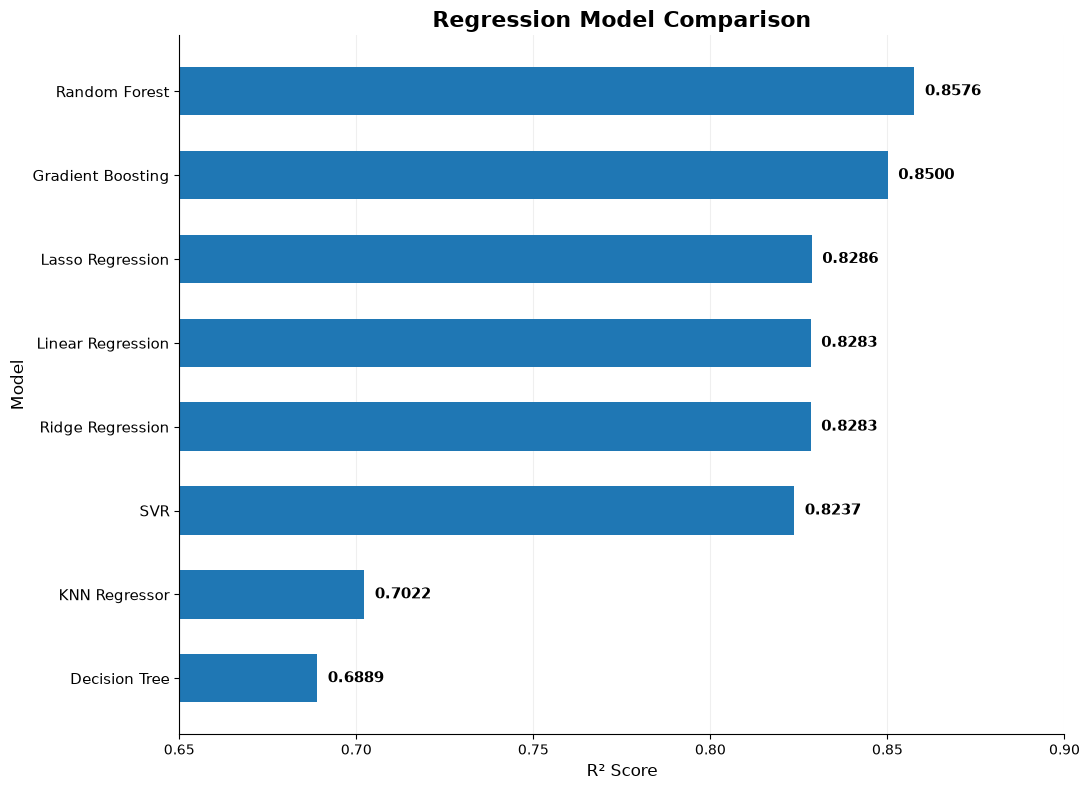

In [5]:
# 4.2. Model Comparison Based on R²

# Sort by R²
model_results = regression_results[["Model", "R2"]].sort_values("R2", ascending=True)

# Increase spacing between models
y_position = np.arange(len(model_results)) * 1.3

plt.figure(figsize=(11, 8))

# Thinner bars
bars = plt.barh(y_position, model_results["R2"], height=0.75)

# Add R² values
for bar, value in zip(bars, model_results["R2"]):
    plt.text(
        value + 0.003,
        bar.get_y() + bar.get_height()/2,
        f"{value:.4f}",
        va="center",
        fontsize=11,
        fontweight="bold"
    )


# Model names
plt.yticks(y_position, model_results["Model"], fontsize=11)

# Labels and title
plt.xlabel("R² Score", fontsize=12)
plt.ylabel("Model", fontsize=12)
plt.title("Regression Model Comparison", fontsize=16, fontweight="bold")

# Keep your useful zoom
plt.xlim(0.65, 0.90)

# Light gridlines only on x-axis
plt.grid( axis="x", alpha=0.2)

# Put grid behind bars
plt.gca().set_axisbelow(True)

# Remove unnecessary borders
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)

plt.tight_layout()
plt.show()

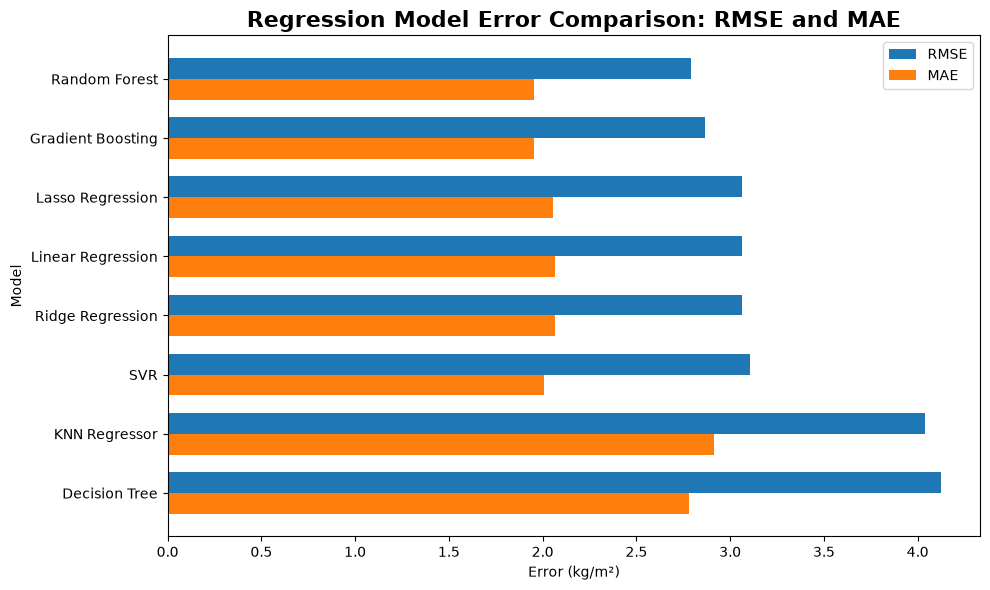

In [6]:
# 4.3. Model Comparison Based on Prediction Error

# Select RMSE and MAE results directly from the model comparison table
error_results = regression_results[
    ["Model", "RMSE", "MAE"]
].sort_values("RMSE", ascending=False)

# Plot RMSE and MAE
plt.figure(figsize=(10, 6))

y_position = range(len(error_results))
height = 0.35

plt.barh(
    [i + height/2 for i in y_position],
    error_results["RMSE"],
    height=height,
    label="RMSE"
)

plt.barh(
    [i - height/2 for i in y_position],
    error_results["MAE"],
    height=height,
    label="MAE"
)

plt.yticks(y_position, error_results["Model"])
plt.xlabel("Error (kg/m²)")
plt.ylabel("Model")
plt.title("Regression Model Error Comparison: RMSE and MAE", fontsize=16, fontweight="bold")
plt.legend()

plt.tight_layout()
plt.show()

#### Comparison of Regression Models

Eight regression algorithms were evaluated using the same training and test datasets. 

Random Forest achieved the strongest overall performance, with the highest R² (0.8576), lowest RMSE (2.79 kg/m²), and lowest MAE (1.95 kg/m²).

Gradient Boosting was the second-best model, with an R² of 0.8500 and performance close to Random Forest. 

Linear, Ridge and Lasso Regression produced similar results, with R² values of approximately 0.83. 

SVR performed slightly below the linear models based on R², while KNN and Decision Tree Regression showed substantially weaker performance.

The stronger performance of Random Forest and Gradient Boosting suggests that nonlinear relationships and interactions among predictors may contribute to BMI prediction. 

Random Forest was therefore selected for further evaluation.

In [7]:
# Save result as a Table
regression_results.round(4).to_csv(
    "../outputs/regression_model_comparison.csv",
    index=False
)

### Step 5. Random Forest Without Waist Circumference: Sensitivity Analysis and Hyperparameter Tuning

Waist circumference showed a very strong correlation with BMI during EDA
(r = 0.910) and was the dominant Random Forest predictor.

To assess the extent to which model performance depended on this closely related
anthropometric measurement, Random Forest was re-evaluated after excluding waist
circumference.

The no-waist model was subsequently tuned using RandomizedSearchCV and
cross-validation.

#### 5.1. Sensitivity Analysis

Exploratory analysis identified a very strong correlation between waist circumference (BMXWAIST) and BMI (r = 0.910), and waist circumference was also the dominant predictor in the Random Forest model.

To assess how strongly model performance depended on this closely related anthropometric measurement, Random Forest was re-evaluated after excluding waist circumference. All other modelling procedures were kept consistent.

In [8]:
predictors_no_waist = [col for col in predictor_vars if col != "BMXWAIST"]

continuous_no_waist = [col for col in continuous_features if col != "BMXWAIST"]

X_no_waist = df[predictors_no_waist].copy()

X_train_nw, X_test_nw, y_train_nw, y_test_nw = train_test_split(
    X_no_waist, y,
    test_size=0.20,
    random_state=42)

preprocessor_no_waist = ColumnTransformer([
    ("num", numeric_transformer, continuous_no_waist),
    ("cat", categorical_transformer, categorical_features)
])

rf_no_waist = Pipeline([
    ("preprocessor", preprocessor_no_waist),
    ("regressor", RandomForestRegressor( n_estimators=200, random_state=42, n_jobs=-1))
])

rf_no_waist.fit(X_train_nw, y_train_nw)

y_pred_nw = rf_no_waist.predict(X_test_nw)

baseline_nw = {
    "R2": r2_score(y_test_nw, y_pred_nw),
    "RMSE": np.sqrt(mean_squared_error(y_test_nw, y_pred_nw)),
    "MAE": mean_absolute_error(y_test_nw, y_pred_nw)
}

baseline_nw

{'R2': 0.49671299809132696,
 'RMSE': np.float64(5.248396044618068),
 'MAE': 3.7747624668043667}

#### Effect of Removing Waist Circumference
Removing waist circumference substantially reduced Random Forest performance. R² decreased from 0.8576 to 0.4967, while RMSE increased from 2.79 to 5.25 kg/m² and MAE increased from 1.95 to 3.77 kg/m².

This indicates that waist circumference contributed substantially to BMI prediction, consistent with the strong correlation observed during exploratory analysis (r = 0.910).

Despite this reduction, the model without waist circumference still explained approximately 49.7% of the variation in BMI, indicating that the remaining demographic, socioeconomic, lifestyle and clinical predictors retained meaningful predictive information.

In [9]:
# 5.2. Hyperparameter Tuning — Random Forest Without Waist Circumference

rf_tuning_pipeline = Pipeline([
    ("preprocessor", preprocessor_no_waist),
    ("regressor", RandomForestRegressor(random_state=42, n_jobs=1))
])

param_distributions = {
    "regressor__n_estimators": [100, 200, 300, 500],
    "regressor__max_depth": [None, 10, 20, 30],
    "regressor__min_samples_split": [2, 5, 10],
    "regressor__min_samples_leaf": [1, 2, 4],
    "regressor__max_features": ["sqrt", 0.5, 1.0]
}

random_search = RandomizedSearchCV(
    rf_tuning_pipeline,
    param_distributions=param_distributions,
    n_iter=20,
    cv=3,
    scoring="r2",
    random_state=42,
    n_jobs=1
)

random_search.fit(X_train_nw, y_train_nw)

best_rf_no_waist = random_search.best_estimator_

y_pred_tuned = best_rf_no_waist.predict(X_test_nw)

tuned_nw = {
    "R2": r2_score(y_test_nw, y_pred_tuned),
    "RMSE": np.sqrt(mean_squared_error(y_test_nw, y_pred_tuned)),
    "MAE": mean_absolute_error(y_test_nw, y_pred_tuned)
}

print("Best parameters:")
print(random_search.best_params_)

print("\nBaseline without waist:")
print(baseline_nw)

print("\nTuned without waist:")
print(tuned_nw)

Best parameters:
{'regressor__n_estimators': 300, 'regressor__min_samples_split': 10, 'regressor__min_samples_leaf': 4, 'regressor__max_features': 0.5, 'regressor__max_depth': None}

Baseline without waist:
{'R2': 0.49671299809132696, 'RMSE': np.float64(5.248396044618068), 'MAE': 3.7747624668043667}

Tuned without waist:
{'R2': 0.5073679685554987, 'RMSE': np.float64(5.192542570391866), 'MAE': 3.7099294547615074}


In [10]:
# 5.3. Comparison of Random Forest Models With and Without Waist Circumference

# Comprison Table
waist_comparison = pd.DataFrame({
    "Model": [
        "Random Forest with waist",
        "Random Forest without waist",
        "Tuned Random Forest without waist"
    ],
    "R2": [
        0.8576,
        baseline_nw["R2"],
        tuned_nw["R2"]
    ],
    "RMSE": [
        2.7918,
        baseline_nw["RMSE"],
        tuned_nw["RMSE"]
    ],
    "MAE": [
        1.9518,
        baseline_nw["MAE"],
        tuned_nw["MAE"]
    ]
})

waist_comparison.round(4)

,Model,R2,RMSE,MAE
0,Random Forest with waist,0.8576,2.7918,1.9518
1,Random Forest without waist,0.4967,5.2484,3.7748
2,Tuned Random Forest without waist,0.5074,5.1925,3.7099


Hyperparameter tuning produced only a modest improvement after waist circumference was excluded. 

Despite optimization, the tuned no-waist model remained substantially weaker than the Random Forest model that included waist circumference. This indicates that the loss of predictive performance associated with removing waist circumference could not be recovered through model tuning alone and that waist circumference provides substantial predictive information for BMI.

### Step 6. Final Random Forest Evaluation

Random Forest was selected as the strongest regression model. Model predictions, residuals and feature importance were examined to assess model behaviour and identify the predictors contributing most strongly to BMI prediction.

In [11]:
rf_final = fitted_models["Random Forest"]
y_pred_rf = rf_final.predict(X_test)

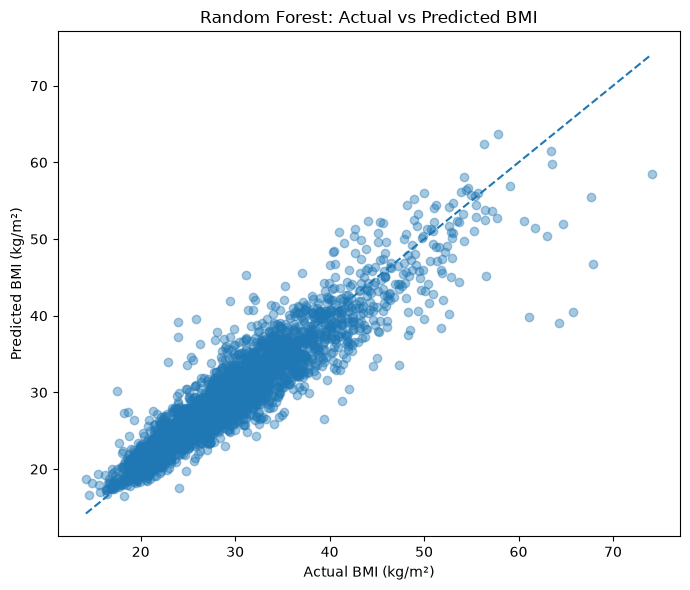

In [12]:
# 6.1. Actual vs Predicted BMI
plt.figure(figsize=(7, 6))

plt.scatter(y_test, y_pred_rf, alpha=0.4)

plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], linestyle="--")

plt.xlabel("Actual BMI (kg/m²)")
plt.ylabel("Predicted BMI (kg/m²)")
plt.title("Random Forest: Actual vs Predicted BMI")

plt.tight_layout()
plt.show()

Actual vs Predicted BMI
Predicted BMI values generally followed the observed values, with most observations clustering around the line of perfect agreement. Greater dispersion was observed at higher BMI values, with some very high BMI values being underpredicted by the model. 

This suggests that prediction error increased for some participants at the upper end of the BMI distribution.

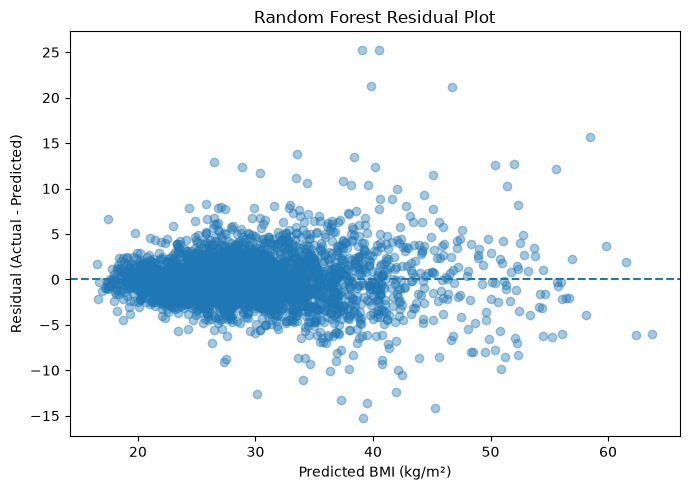

In [13]:
# 6.2. Residual Plot
residuals = y_test - y_pred_rf

plt.figure(figsize=(7, 5))

plt.scatter(y_pred_rf, residuals, alpha=0.4)

plt.axhline(0, linestyle="--")

plt.xlabel("Predicted BMI (kg/m²)")
plt.ylabel("Residual (Actual - Predicted)")
plt.title("Random Forest Residual Plot")

plt.tight_layout()
plt.show()

#### Residual Analysis

Residuals were generally distributed around zero, suggesting no strong systematic tendency to overpredict or underpredict BMI. However, the residual spread increased at higher predicted BMI values, indicating greater prediction uncertainty among participants with higher BMI. Several relatively large residuals were also observed.

In [14]:
# 6.3. Random Forest Feature Importance
# Get fitted preprocessor
fitted_preprocessor = rf_final.named_steps["preprocessor"]

# Continuous feature names
numeric_names = continuous_features

# One-hot encoded categorical feature names
categorical_names = (
    fitted_preprocessor
    .named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(categorical_features)
)

# Combine feature names
feature_names = list(numeric_names) + list(categorical_names)

# Extract feature importance
importances = (rf_final.named_steps["regressor"].feature_importances_)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances}).sort_values(
    "Importance",ascending=False
).reset_index(drop=True)

feature_importance.head(15)

,Feature,Importance
0,BMXWAIST,0.7715
1,WHQ030_1.0,0.0299
2,RIDAGEYR,0.0283
3,LBXGH,0.0160
4,LBDHDD,0.0147
5,LBXTC,0.0140
6,INDFMPIR,0.0137
7,BPXDI1,0.0121
8,BPXSY1,0.0112
9,PAD680,0.0108


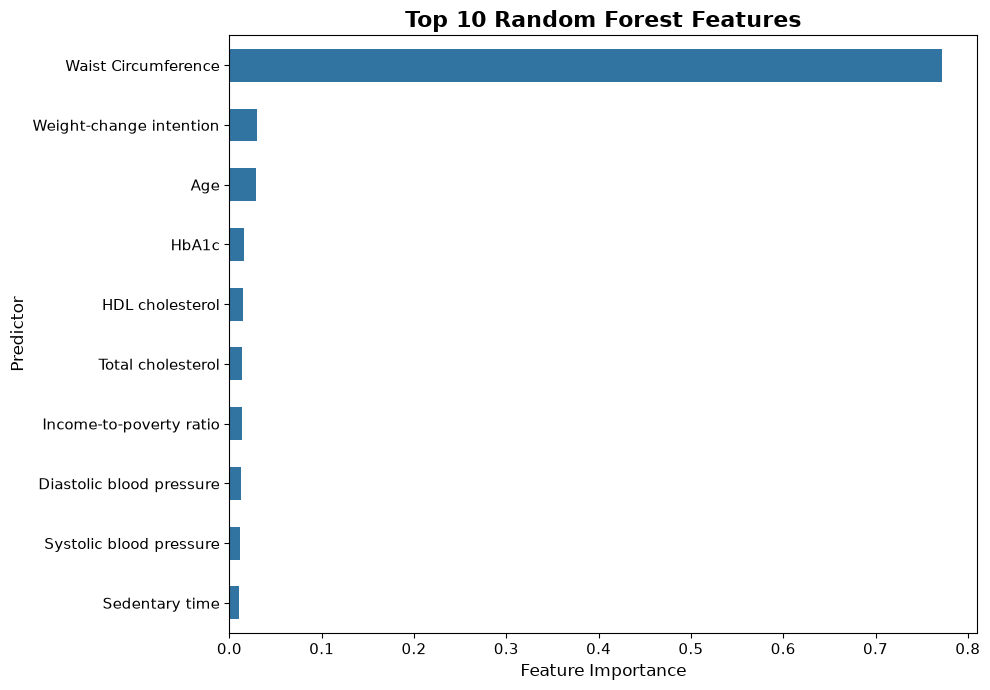

In [15]:
# Create readable names for the features
feature_labels = {
    "BMXWAIST": "Waist Circumference",
    "WHQ030_1.0": "Weight-change intention",
    "RIDAGEYR": "Age",
    "LBXGH": "HbA1c",
    "LBDHDD": "HDL cholesterol",
    "LBXTC": "Total cholesterol",
    "INDFMPIR": "Income-to-poverty ratio",
    "BPXDI1": "Diastolic blood pressure",
    "BPXSY1": "Systolic blood pressure",
    "PAD680": "Sedentary time"
}

# Select top 10 features
top_features = feature_importance.head(10).copy()

# Replace coded names with readable names
top_features["Feature_Label"] = top_features["Feature"].map(
    feature_labels
).fillna(top_features["Feature"])

# Plot
plt.figure(figsize=(10, 7))

ax = sns.barplot(
    data=top_features,
    y="Feature_Label",
    x="Importance",
    width=0.55
)

plt.title(
    "Top 10 Random Forest Features",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Feature Importance", fontsize=12)
plt.ylabel("Predictor", fontsize=12)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

Waist circumference (BMXWAIST) was by far the most important predictor according to the Random Forest feature-importance measure, with an importance of approximately 0.771. This was consistent with the strong correlation between waist circumference and BMI observed during exploratory analysis (r = 0.910).

Other predictors contributed substantially less individually. These included weight-change intention, age, HbA1c, HDL cholesterol, total cholesterol, income-to-poverty ratio, blood pressure and sedentary time.

The dominance of waist circumference helps explain the substantial reduction in Random Forest performance when this variable was excluded, with R² decreasing from 0.8576 to 0.4967. 

Hyperparameter tuning of the no-waist model improved R² only modestly to 0.5074.

Feature importance reflects a predictor's contribution to prediction within this fitted Random Forest model and should not be interpreted as evidence of a causal effect on BMI.

In [16]:
# 6.4. Feature Importance Without Waist Circumference
# Get fitted preprocessor from the no-waist model
fitted_preprocessor_nw = rf_no_waist.named_steps["preprocessor"]

# Continuous feature names used in the no-waist model
numeric_names_nw = continuous_no_waist

# One-hot encoded categorical feature names
categorical_names_nw = (
    fitted_preprocessor_nw
    .named_transformers_["cat"]
    .named_steps["onehot"]
    .get_feature_names_out(categorical_features)
)

# Combine feature names
feature_names_nw = list(numeric_names_nw) + list(categorical_names_nw)

# Extract feature importances from the no-waist Random Forest
importances_nw = rf_no_waist.named_steps["regressor"].feature_importances_

feature_importance_nw = pd.DataFrame({
    "Feature": feature_names_nw,
    "Importance": importances_nw
}).sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

feature_importance_nw.head(15)

,Feature,Importance
0,WHQ030_1.0,0.3431
1,LBDHDD,0.0684
2,RIDAGEYR,0.0678
3,LBXGH,0.0596
4,LBXTC,0.0562
5,BPXSY1,0.0529
6,INDFMPIR,0.0504
7,BPXDI1,0.0417
8,PAD680,0.0406
9,RIDRETH3_6.0,0.0303


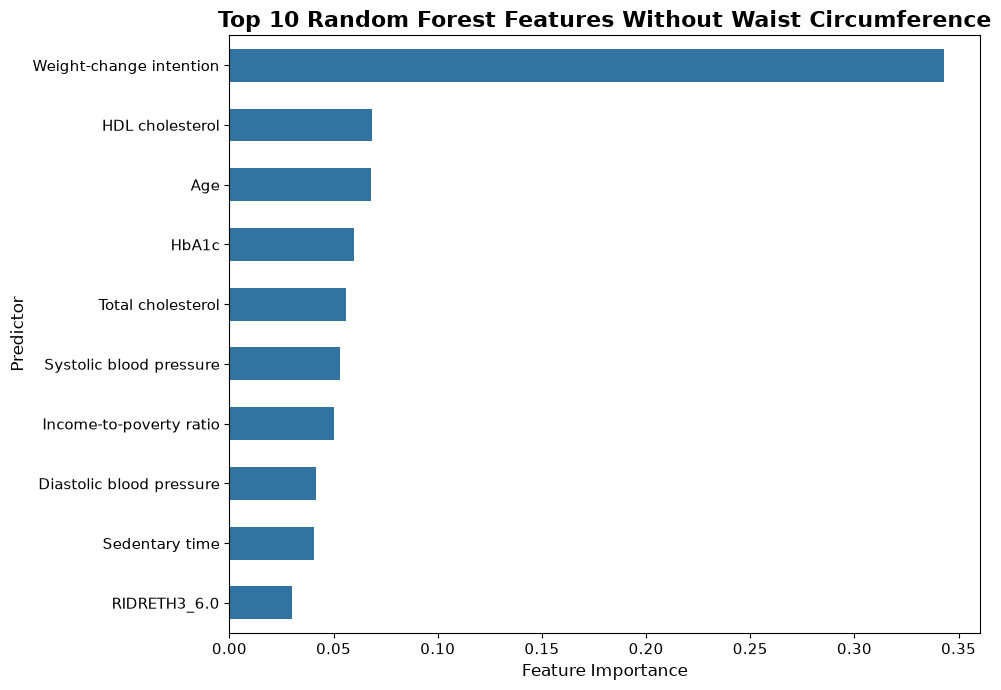

In [17]:
# Readable feature labels
feature_labels_nw = {
    "WHQ030_1.0": "Weight-change intention",
    "RIDAGEYR": "Age",
    "LBXGH": "HbA1c",
    "LBDHDD": "HDL cholesterol",
    "LBXTC": "Total cholesterol",
    "INDFMPIR": "Income-to-poverty ratio",
    "BPXDI1": "Diastolic blood pressure",
    "BPXSY1": "Systolic blood pressure",
    "PAD680": "Sedentary time",
    "RIAGENDR_1.0": "Sex: Male",
    "RIAGENDR_2.0": "Sex: Female"
}

# Select top 10 features
top_features_nw = feature_importance_nw.head(10).copy()

# Replace codes with readable labels
top_features_nw["Feature_Label"] = top_features_nw["Feature"].map(
    feature_labels_nw
).fillna(top_features_nw["Feature"])

# Plot
plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features_nw,
    y="Feature_Label",
    x="Importance",
    width=0.55
)

plt.title(
    "Top 10 Random Forest Features Without Waist Circumference",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Feature Importance", fontsize=12)
plt.ylabel("Predictor", fontsize=12)

plt.xticks(fontsize=11)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

##### Feature Importance Without Waist Circumference
After waist circumference was excluded, weight-change intention became the dominant predictor, with a feature importance of approximately 0.343. HDL cholesterol, age, HbA1c, total cholesterol, systolic blood pressure and income-to-poverty ratio were the next most important predictors, although their individual contributions were substantially smaller.

The redistribution of feature importance indicates that, in the absence of waist circumference, the Random Forest model relied more heavily on a combination of behavioural, demographic and clinical characteristics. However, the lower R² of the no-waist model (0.4967) shows that these predictors did not collectively reproduce the predictive performance achieved when waist circumference was included.

### Step 7. Regression Conclusion

Eight regression algorithms were evaluated for predicting BMI among adult NHANES participants.

Random Forest achieved the strongest predictive performance, with an R² of 0.8576, RMSE of 2.79 kg/m² and MAE of 1.95 kg/m². Gradient Boosting was the second-best model.

Feature-importance analysis identified waist circumference as the dominant Random Forest predictor. Removing waist circumference reduced model R² from 0.8576 to 0.4967. Hyperparameter tuning improved the no-waist model only modestly to R² = 0.5074.

These findings indicate that BMI can be predicted with high performance when another anthropometric measurement is available. Demographic, socioeconomic, lifestyle and clinical characteristics retained moderate predictive ability when waist circumference was excluded.

The sensitivity analysis highlights the importance of evaluating predictor relationships and model interpretability rather than selecting a model solely on the basis of its highest predictive score.

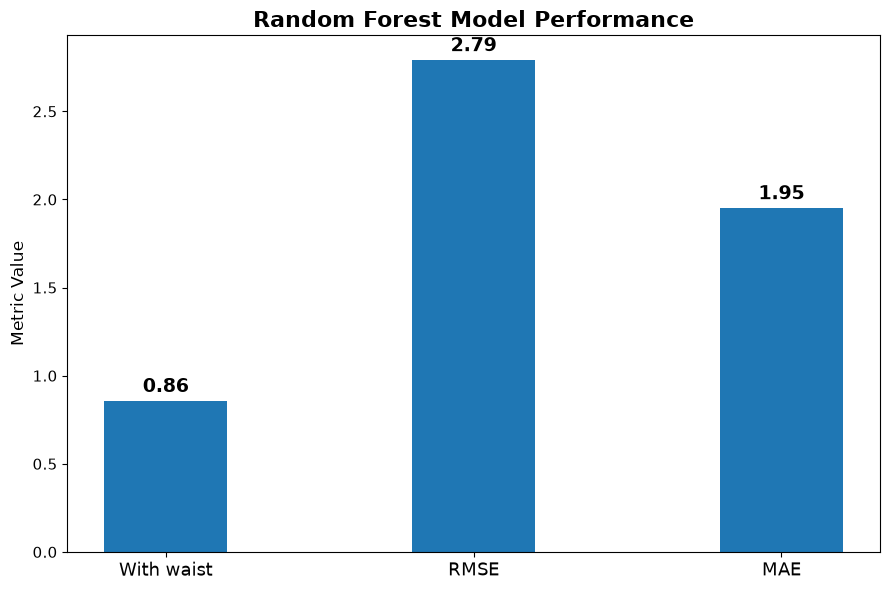

In [18]:
metrics = ["With waist", "RMSE", "MAE"]
values = [0.8576, 2.7918, 1.9518]

plt.figure(figsize=(9, 6))

bars = plt.bar(
    metrics,
    values,
    width=0.4
)

# Add values above bars
for bar, value in zip(bars, values):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.05,
        f"{value:.2f}",
        ha="center",
        fontsize=14,
        fontweight="bold"
    )

plt.title(
    "Random Forest Model Performance",
    fontsize=16,
    fontweight="bold"
)

plt.ylabel("Metric Value", fontsize=12)
plt.xticks(fontsize=13)
plt.yticks(fontsize=11)

plt.tight_layout()
plt.show()

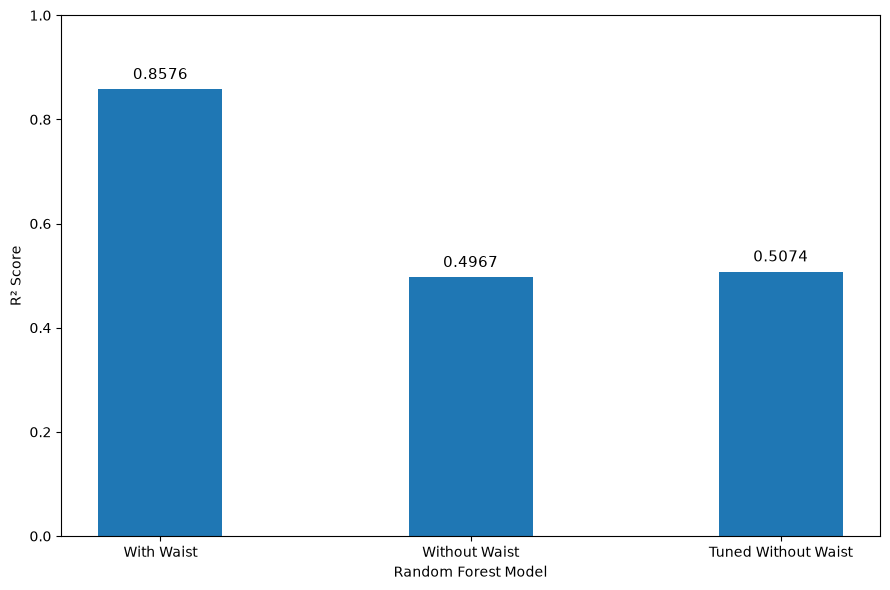

In [19]:
# Random Forest R² results
models = [
    "With Waist",
    "Without Waist",
    "Tuned Without Waist"
]

r2_scores = [
    0.8576,
    0.4967,
    0.5074
]

# Create bar chart
plt.figure(figsize=(9, 6))

bars = plt.bar(models, r2_scores, width=0.4)

# Add values above bars
for bar, value in zip(bars, r2_scores):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.02,
        f"{value:.4f}",
        ha="center",
        fontsize=11
    )

# plt.title("Random Forest Performance With and Without Waist Circumference")
plt.ylabel("R² Score")
plt.xlabel("Random Forest Model")
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

## Final Summary
Overall, Random Forest was the best-performing model for BMI prediction. 

However, its strong performance was largely dependent on waist circumference. When waist circumference was excluded, predictive performance declined substantially and was only modestly improved through hyperparameter tuning. 

These results demonstrate the value of combining model-performance evaluation with sensitivity analysis and feature interpretation when assessing machine-learning models for BMI prediction.